MAE: 20.78
RMSE: 36.18
R²: 0.9150


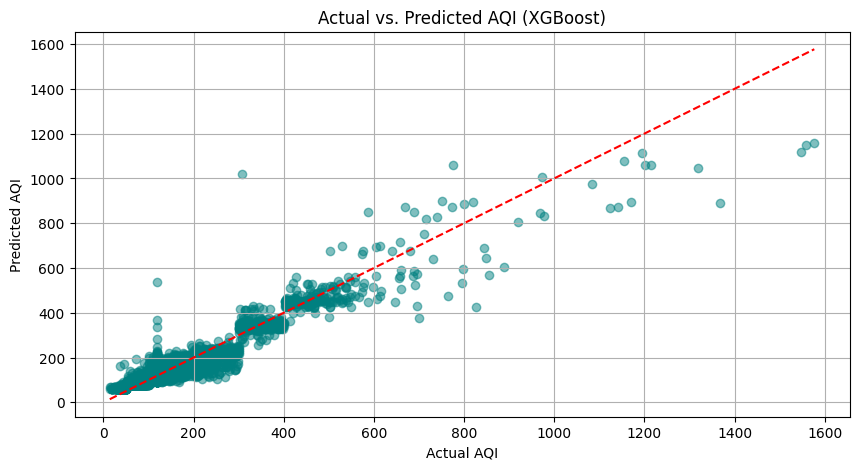

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('./AirQuality_Cleaned.csv')

# Drop non-numeric or irrelevant columns like 'Date'
if 'Date' in data.columns:
    data = data.drop(columns=['Date'])

# Set the target column
target_column = 'AQI'

# Features and target
X = data.drop(columns=[target_column])
y = data[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=40,           
    learning_rate=0.1,
    max_depth=2,                
    subsample=0.6,              
    colsample_bytree=0.6,       
    random_state=40
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs. Predicted AQI (XGBoost)")
plt.grid(True)
plt.show()
